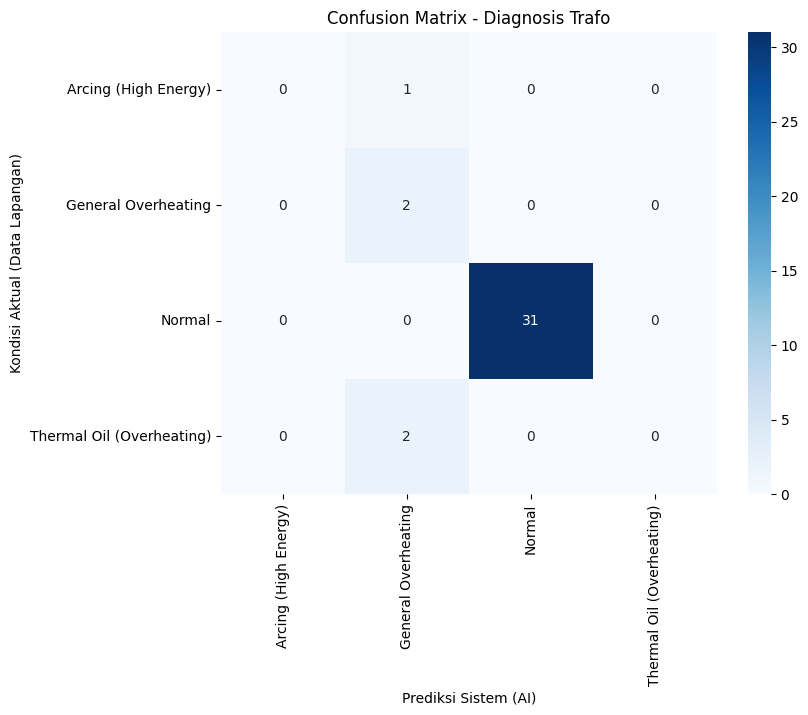

                           precision    recall  f1-score   support

     Arcing (High Energy)       0.00      0.00      0.00         1
      General Overheating       0.40      1.00      0.57         2
                   Normal       1.00      1.00      1.00        31
Thermal Oil (Overheating)       0.00      0.00      0.00         2

                 accuracy                           0.92        36
                macro avg       0.35      0.50      0.39        36
             weighted avg       0.88      0.92      0.89        36



c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- LOAD & PREPARE DATA ---
df = pd.read_csv('DATASET_RIIL_22-25.csv')

# Fungsi Auto-Labeling (Sama seperti sebelumnya)
def get_key_gas_diagnosis(row):
    h2 = row['H2']; ch4 = row['CH4']; c2h6 = row['C2H6']
    c2h4 = row['C2H4']; c2h2 = row['C2H2']; co = row['CO']
    tdcg = h2 + ch4 + c2h6 + c2h4 + c2h2 + co
    
    if tdcg < 720: return "Normal"
    if c2h2 > 10 and c2h2 > h2: return "Arcing (High Energy)"
    if c2h4 > c2h6 and c2h4 > ch4: return "Thermal Oil (Overheating)"
    if h2 > 100 and h2 > ch4 and h2 > c2h4: return "Partial Discharge (Corona)"
    if co > 1000: return "Cellulose Degradation"
    return "General Overheating"

df['Fault_Type'] = df.apply(get_key_gas_diagnosis, axis=1)
df['TDCG'] = df['H2'] + df['CH4'] + df['C2H6'] + df['C2H4'] + df['C2H2'] + df['CO']

features = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'CO', 'CO2', 'TDCG']
X = df[features]
y = df['Fault_Type']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- VISUALISASI CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y_test.unique())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Diagnosis Trafo')
plt.ylabel('Kondisi Aktual (Data Lapangan)')
plt.xlabel('Prediksi Sistem (AI)')
plt.show()

# --- PRINT REPORT ---
print(classification_report(y_test, y_pred))